✅ Step 1 — Problem Statement

In this project, the objective is to build a regression model to predict the fuel efficiency (MPG) of cars using various vehicle and engine features.
This helps in understanding how different factors influence car mileage.

✅ Step 2 — Importing Libraries

Required Python libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn were imported for data handling, visualization, and machine learning model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

✅ Step 3 — Dataset Loading

The Auto-MPG dataset was loaded into a Pandas DataFrame to explore the structure and understand the available features such as horsepower, weight, cylinders, and acceleration.

In [6]:
df = pd.read_csv(r"C:\Users\Aamir choudhary\OneDrive\Documents\auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [7]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
393,27.0,4,140.0,86.0,2790,15.6,82
394,44.0,4,97.0,52.0,2130,24.6,82
395,32.0,4,135.0,84.0,2295,11.6,82
396,28.0,4,120.0,79.0,2625,18.6,82
397,31.0,4,119.0,82.0,2720,19.4,82


✅ Step 4 — Data Understanding

The dataset was analyzed using functions like info() and describe() to understand data types, feature distributions, and the presence of missing values.
The dataset was found to be clean and suitable for model training.

In [8]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
count,398.000000,398.000000,398.000000,396.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.189394,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.402030,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,92.000000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    396 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model-year    398 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 21.9 KB


In [19]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model-year      0
dtype: int64

✅ Step 5 — Data Cleaning

Missing values and non-numeric data were handled by replacing invalid entries and removing unnecessary columns.
This step ensures that the dataset is clean and suitable for machine learning model training.

In [20]:
df.dropna(inplace=True)

✅ Step 6 — Data Visualization

A scatter plot was created to analyze the relationship between vehicle weight and fuel efficiency.
This helps in identifying patterns and understanding feature influence on mileage.

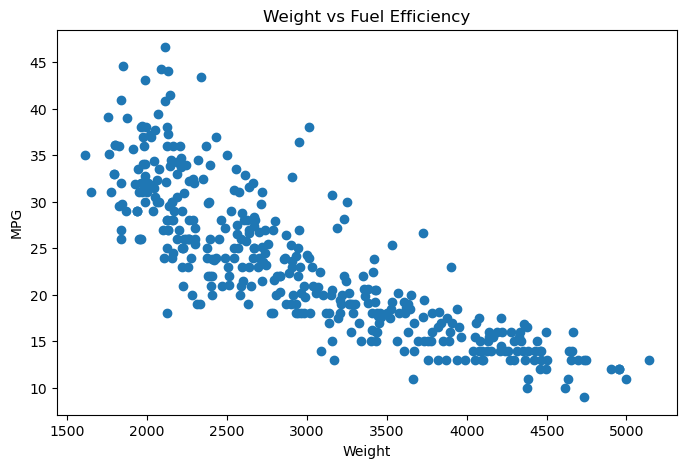

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df['weight'], df['mpg'])
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Weight vs Fuel Efficiency")
plt.show()

✅ Step 7 — Feature Selection

Input features (independent variables) were separated from the target variable (MPG).
This allows the model to learn the relationship between vehicle characteristics and fuel efficiency.

In [22]:
X = df.drop('mpg', axis=1)
y = df['mpg']

✅ Step 8 — Train-Test Splitting

The dataset was divided into training and testing sets using an 80-20 ratio.
This helps evaluate model performance on unseen data.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

✅ Step 9 — Feature Scaling

Standardization was applied to normalize the feature values.
Feature scaling improves model stability and prediction performance.

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

✅ Step 10 — Model Training

A Linear Regression model was trained using the training dataset.
This algorithm is suitable for predicting continuous numerical values like fuel efficiency.

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


✅ Step 11 — Prediction

The trained model was used to predict MPG values for the testing dataset.
This step helps analyze how well the model performs on new data.

In [26]:
y_pred = model.predict(X_test)

✅ Step 12 — Model Evaluation

Model performance was evaluated using Mean Squared Error (MSE) and R² Score.
These metrics help measure prediction accuracy and overall model effectiveness.

In [27]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 10.816398854150894
R2 Score: 0.7915221520428833


✅ Step 13 — Visualization of Results

A scatter plot comparing actual and predicted MPG values was created to visually assess model accuracy.
Points closer to the diagonal trend indicate better prediction performance.

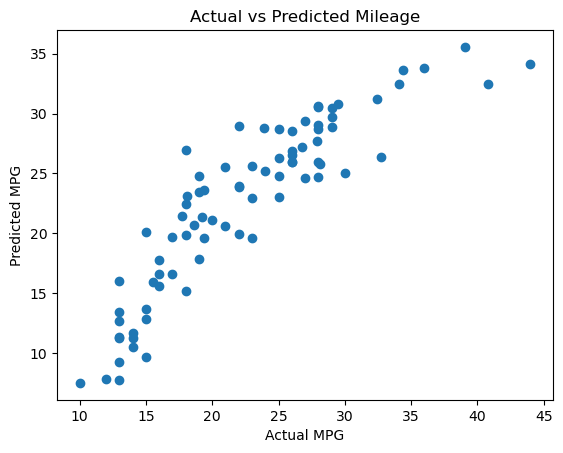

In [28]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted Mileage")
plt.show()